# Úkol 5


In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, convolve2d
from IPython.display import Audio, display
from scipy.io import wavfile
from PIL import Image

warnings.filterwarnings("ignore")


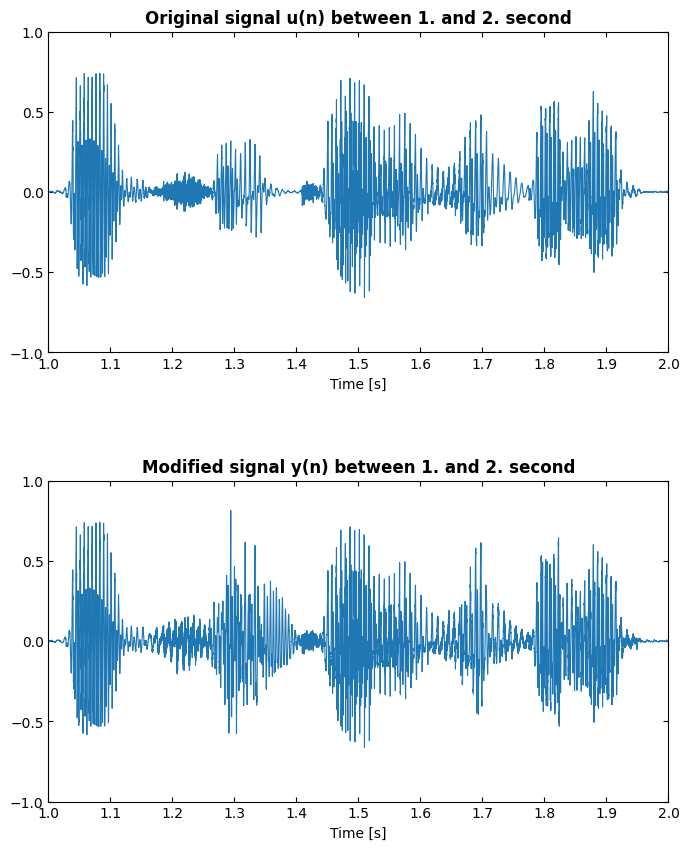

In [2]:
fs, u_raw = wavfile.read("voice_short.wav")
if u_raw.ndim > 1:
    u_raw = u_raw[:, 0]
u = u_raw / np.max(np.abs(u_raw))

g_audio = np.zeros(fs + 1)
g_audio[0] = 1.0
g_audio[fs] = 0.5

y = convolve(u, g_audio, mode='full')

t_u = np.arange(len(u)) / fs
t_y = np.arange(len(y)) / fs

mask_u = (t_u >= 1.0) & (t_u <= 2.0)
mask_y = (t_y >= 1.0) & (t_y <= 2.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
fig.subplots_adjust(hspace=0.4)

ax1.plot(t_u[mask_u], u[mask_u], linewidth=0.8)
ax1.set_title("Original signal u(n) between 1. and 2. second", fontweight='bold')
ax1.set_xlabel("Time [s]")
ax1.set_xlim(1.0, 2.0)
ax1.set_ylim(-1.0, 1.0)
ax1.set_xticks(np.arange(1.0, 2.1, 0.1))
ax1.set_yticks(np.arange(-1.0, 1.5, 0.5))
ax1.tick_params(axis='both', direction='in', top=True, right=True, bottom=True, left=True)

ax2.plot(t_y[mask_y], y[mask_y], linewidth=0.8)
ax2.set_title("Modified signal y(n) between 1. and 2. second", fontweight='bold')
ax2.set_xlabel("Time [s]")
ax2.set_xlim(1.0, 2.0)
ax2.set_ylim(-1.0, 1.0)
ax2.set_xticks(np.arange(1.0, 2.1, 0.1))
ax2.set_yticks(np.arange(-1.0, 1.5, 0.5))
ax2.tick_params(axis='both', direction='in', top=True, right=True, bottom=True, left=True)

plt.show()

display(Audio(u, rate=fs))
display(Audio(y, rate=fs))


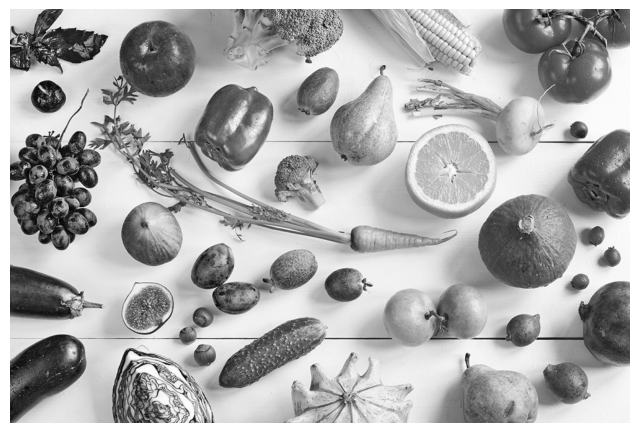

In [3]:
image_array = np.array(Image.open("fruit_grey.jpg").convert('L'))

g1 = np.array([[0, -1, 0],
               [-1, 4, -1],
               [0, -1, 0]])

g2 = np.array([[-1, -1, -1],
               [-1, 8, -1],
               [-1, -1, -1]])

g3 = (1/25) * np.ones((5, 5))

g4 = (1/256) * np.array([[1, 4, 6, 4, 1],
                         [4, 16, 24, 16, 4],
                         [6, 24, 36, 24, 6],
                         [4, 16, 24, 16, 4],
                         [1, 4, 6, 4, 1]])

def apply_image_filter(image, kernel):
    filtered_image = convolve2d(image, kernel, mode='same', boundary='symm')
    f = np.abs(filtered_image)
    plt.figure(figsize=(8, 8))
    plt.imshow(f, cmap='gray')
    plt.axis('off')
    plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()


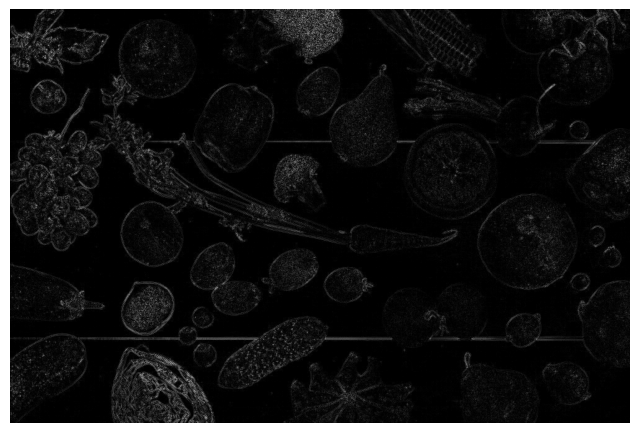

In [4]:
apply_image_filter(image_array, g1)


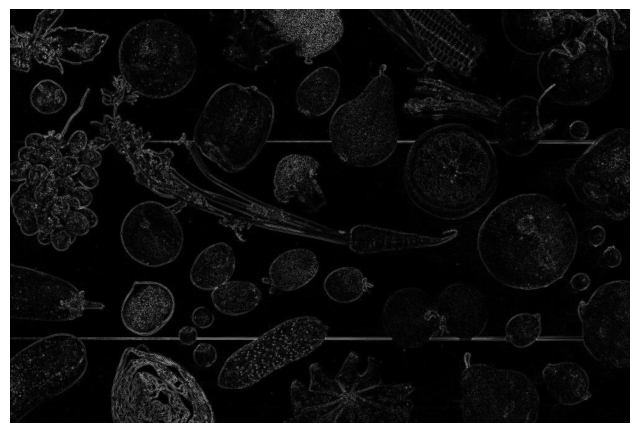

In [5]:
apply_image_filter(image_array, g2)


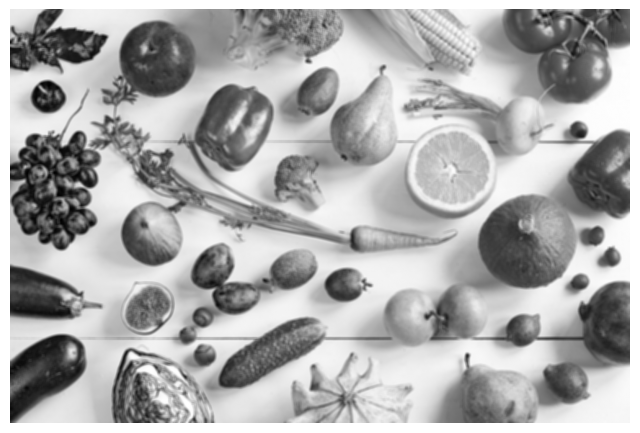

In [6]:
apply_image_filter(image_array, g3)


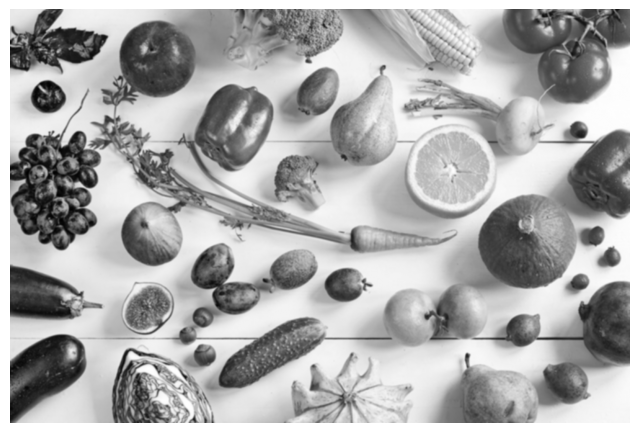

In [7]:
apply_image_filter(image_array, g4)


## Komentář
Nejprve jsem importoval nezbytné knihovny. Následně jsem načetl audiosignál `voice_short.wav`, v případě vícekanálového záznamu ponechal pouze první kanál a signál normalizoval vydělením maximální absolutní hodnotou, aby se amplituda pohybovala v rozsahu $\langle -1, 1 \rangle$.

Impulsní odezvu $g(n)$ jsem navrhl jako posloupnost délky $f_s + 1$ vzorků inicializovanou nulami, kde $g(0) = 1{,}0$ zajišťuje průchod původního signálu beze změny a $g(f_s) = 0{,}5$ realizuje ozvěnu posunutou o přesně 1 sekundu s poloviční intenzitou. Modifikovaný signál $y(n) = u(k) * g(k)$ jsem vypočítal pomocí funkce `scipy.signal.convolve`.

Pro názornou vizualizaci jsem vygeneroval dva grafy pod sebou zobrazující průběhy $u(n)$ a $y(n)$ v intervalu $\langle 1, 2 \rangle$ s. Vizuálním porovnáním obou grafů jsem potvrdil, že $y(n)$ obsahuje superpozici aktuálního signálu s jeho verzí zpožděnou o 1 sekundu a s poloviční amplitudou. Oba signály jsem si rovněž poslechl, čímž jsem ověřil výrazně slyšitelný efekt ozvěny.

Pro obrazový signál jsem načetl soubor `fruit_grey.jpg`, převedl jej do stupňů šedi a uložil jako pole `numpy`. Definoval jsem čtyři konvoluční jádra přesně podle zadání: $g_1$, $g_2$, $g_3$ a $g_4$. Každé jádro jsem aplikoval pomocí funkce `scipy.signal.convolve2d` a výsledný obraz zobrazil. Postupnou aplikací všech čtyř kernelů jsem vizuálně ověřil jejich odlišný efekt na obrazový signál.
